# 99 — Final Comparison: All Methods

Compares current best version of each model:
- **SVM v2**: handcrafted features + RBF kernel (pooled)
- **CNN v2**: StandardCNN 2D (baseline DL)
- **SCNN v7**: Separable CNN + FHT envelope + ECA attention
- **1D-CNN v6**: TemporalSCNN 1D + ECA attention

All models use identical calibration: `LogisticRegression(C=1.0, max_iter=1000)`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
matplotlib.rcParams.update({'font.size': 11})

scenarios = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
scenario_names = {
    'S1': 'Ideal',
    'S2': 'Electrode\nShift',
    'S3': 'Inter-\nSubject',
    'S4': 'Inter-\nDay',
    'S5': 'Fatigue',
    'S6': 'Combined',
}

# ============================================================
# RESULTS — from SVM_v2, CNN_v2, SCNN_v7, CNN1D_v6
# All calibration: LogisticRegression(C=1.0, max_iter=1000)
# ============================================================

zero_shot = {
    'SVM':      {'S1': 46.24, 'S2': 39.15, 'S3': 39.79, 'S4': 47.59, 'S5': 53.26, 'S6': 39.15},
    'CNN':      {'S1': 59.14, 'S2': 55.00, 'S3': 55.37, 'S4': 66.69, 'S5': 81.41, 'S6': 55.00},
    'SCNN+FHT': {'S1': 51.97, 'S2': 50.78, 'S3': 50.88, 'S4': 59.57, 'S5': 68.56, 'S6': 50.78},
    '1D-CNN':   {'S1': 58.62, 'S2': 53.52, 'S3': 53.98, 'S4': 65.56, 'S5': 80.29, 'S6': 53.52},
}

calibrated = {
    'SVM':      {'S1': 62.28, 'S2': 62.96, 'S3': 58.17, 'S4': 66.66, 'S5': 74.04, 'S6': 66.91},
    'CNN':      {'S1': 72.66, 'S2': 75.26, 'S3': 78.86, 'S4': 79.32, 'S5': 85.35, 'S6': 82.82},
    'SCNN+FHT': {'S1': 68.35, 'S2': 72.80, 'S3': 75.82, 'S4': 78.27, 'S5': 82.68, 'S6': 81.14},
    '1D-CNN':   {'S1': 70.46, 'S2': 76.57, 'S3': 76.75, 'S4': 81.37, 'S5': 86.23, 'S6': 81.70},
}

s7_shifted_avg = {
    'SVM':      43.72,
    'CNN':      77.66,
    'SCNN+FHT': 62.90,
    '1D-CNN':   79.92,
}

s8_results = {
    'SVM':      {'Zero-shot': 39.62, '1 rep, p0': 25.91, '1 rep, all': 57.87, '2 rep, p0': 28.49, '2 rep, all': 66.30},
    'CNN':      {'Zero-shot': 55.14, '1 rep, p0': 44.79, '1 rep, all': 78.61, '2 rep, p0': 51.19, '2 rep, all': 82.15},
    'SCNN+FHT': {'Zero-shot': 50.72, '1 rep, p0': 44.01, '1 rep, all': 76.25, '2 rep, p0': 47.00, '2 rep, all': 80.45},
    '1D-CNN':   {'Zero-shot': 53.91, '1 rep, p0': 38.93, '1 rep, all': 76.11, '2 rep, p0': 43.97, '2 rep, all': 80.91},
}

params = {'SVM': '—', 'CNN': '101,831', 'SCNN+FHT': '44,764', '1D-CNN': '62,676'}
latency = {'SVM': 4.02, 'CNN': 2.79, 'SCNN+FHT': 4.05, '1D-CNN': 6.97}
methods = ['SVM', 'CNN', 'SCNN+FHT', '1D-CNN']
colors = ['#8B8B8B', '#5B9BD5', '#FFC000', '#70AD47']

## Table 1 — Zero-Shot (No Calibration)

In [2]:
print('=' * 82)
print('  TABLE 1 — ZERO-SHOT')
print('=' * 82)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>14}', end='')
print(f'{"Best":>10}')
print('-' * 82)

for s in scenarios:
    vals = [zero_shot[m][s] for m in methods]
    best_idx = np.argmax(vals)
    print(f'{s:<12}', end='')
    for i, m in enumerate(methods):
        mark = ' *' if i == best_idx else '  '
        print(f'{zero_shot[m][s]:>12.2f}%{mark}', end='')
    print(f'  {methods[best_idx]}')

print('-' * 82)
print(f'{"Average":<12}', end='')
avgs = []
for m in methods:
    avg = np.mean([zero_shot[m][s] for s in scenarios])
    avgs.append(avg)
    print(f'{avg:>12.2f}%  ', end='')
print(f'  {methods[np.argmax(avgs)]}')
print('=' * 82)

  TABLE 1 — ZERO-SHOT
Scenario               SVM           CNN      SCNN+FHT        1D-CNN      Best
----------------------------------------------------------------------------------
S1                 46.24%         59.14% *       51.97%         58.62%    CNN
S2                 39.15%         55.00% *       50.78%         53.52%    CNN
S3                 39.79%         55.37% *       50.88%         53.98%    CNN
S4                 47.59%         66.69% *       59.57%         65.56%    CNN
S5                 53.26%         81.41% *       68.56%         80.29%    CNN
S6                 39.15%         55.00% *       50.78%         53.52%    CNN
----------------------------------------------------------------------------------
Average            44.20%         62.10%         55.42%         60.91%    CNN


## Table 2 — With Calibration

In [3]:
print('=' * 82)
print('  TABLE 2 — WITH CALIBRATION')
print('=' * 82)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>14}', end='')
print(f'{"Best":>10}')
print('-' * 82)

for s in scenarios:
    vals = [calibrated[m][s] for m in methods]
    best_idx = np.argmax(vals)
    print(f'{s:<12}', end='')
    for i, m in enumerate(methods):
        mark = ' *' if i == best_idx else '  '
        print(f'{calibrated[m][s]:>12.2f}%{mark}', end='')
    print(f'  {methods[best_idx]}')

print('-' * 82)
print(f'{"Average":<12}', end='')
avgs = []
for m in methods:
    avg = np.mean([calibrated[m][s] for s in scenarios])
    avgs.append(avg)
    print(f'{avg:>12.2f}%  ', end='')
print(f'  {methods[np.argmax(avgs)]}')
print('=' * 82)

  TABLE 2 — WITH CALIBRATION
Scenario               SVM           CNN      SCNN+FHT        1D-CNN      Best
----------------------------------------------------------------------------------
S1                 62.28%         72.66% *       68.35%         70.46%    CNN
S2                 62.96%         75.26%         72.80%         76.57% *  1D-CNN
S3                 58.17%         78.86% *       75.82%         76.75%    CNN
S4                 66.66%         79.32%         78.27%         81.37% *  1D-CNN
S5                 74.04%         85.35%         82.68%         86.23% *  1D-CNN
S6                 66.91%         82.82% *       81.14%         81.70%    CNN
----------------------------------------------------------------------------------
Average            65.17%         79.05%         76.51%         78.85%    CNN


## Table 3 — Calibration Improvement (Delta)

In [4]:
print('=' * 82)
print('  TABLE 3 — CALIBRATION IMPROVEMENT')
print('=' * 82)
print(f'{"Scenario":<12}', end='')
for m in methods: print(f'{m:>14}', end='')
print()
print('-' * 82)

for s in scenarios:
    print(f'{s:<12}', end='')
    for m in methods:
        delta = calibrated[m][s] - zero_shot[m][s]
        print(f'{delta:>+12.2f}%  ', end='')
    print()

print('-' * 82)
print(f'{"Average":<12}', end='')
for m in methods:
    avg_d = np.mean([calibrated[m][s] - zero_shot[m][s] for s in scenarios])
    print(f'{avg_d:>+12.2f}%  ', end='')
print()
print('=' * 82)

  TABLE 3 — CALIBRATION IMPROVEMENT
Scenario               SVM           CNN      SCNN+FHT        1D-CNN
----------------------------------------------------------------------------------
S1                +16.04%        +13.52%        +16.38%        +11.84%  
S2                +23.81%        +20.26%        +22.02%        +23.05%  
S3                +18.38%        +23.49%        +24.94%        +22.77%  
S4                +19.07%        +12.63%        +18.70%        +15.81%  
S5                +20.78%         +3.94%        +14.12%         +5.94%  
S6                +27.76%        +27.82%        +30.36%        +28.18%  
----------------------------------------------------------------------------------
Average           +20.97%        +16.94%        +21.09%        +17.93%  


## Table 4 — Model Efficiency

In [5]:
print('=' * 62)
print('  TABLE 4 — MODEL EFFICIENCY')
print('=' * 62)
print(f'{"Metric":<20}', end='')
for m in methods: print(f'{m:>12}', end='')
print()
print('-' * 62)
print(f'{"Parameters":<20}', end='')
for m in methods: print(f'{params[m]:>12}', end='')
print()
print(f'{"Latency p95 (ms)":<20}', end='')
for m in methods: print(f'{latency[m]:>12.2f}', end='')
print()
print(f'{"< 300ms":<20}', end='')
for m in methods: print(f'{"yes":>12}', end='')
print()
print('=' * 62)

  TABLE 4 — MODEL EFFICIENCY
Metric                       SVM         CNN    SCNN+FHT      1D-CNN
--------------------------------------------------------------
Parameters                     —     101,831      44,764      62,676
Latency p95 (ms)            4.02        2.79        4.05        6.97
< 300ms                      yes         yes         yes         yes


## Table 5 — S7: Gradual Electrode Shift

In [6]:
print('=' * 62)
print('  TABLE 5 — S7: GRADUAL SHIFT (Avg Shifted Positions)')
print('=' * 62)
print(f'{"Method":<14} {"Avg P1-P10":>12} {"vs CNN":>10} {"vs SVM":>10}')
print('-' * 62)
for m in methods:
    vs_cnn = s7_shifted_avg[m] - s7_shifted_avg['CNN']
    vs_svm = s7_shifted_avg[m] - s7_shifted_avg['SVM']
    print(f'{m:<14} {s7_shifted_avg[m]:>11.2f}% {vs_cnn:>+9.2f}% {vs_svm:>+9.2f}%')
print('=' * 62)

  TABLE 5 — S7: GRADUAL SHIFT (Avg Shifted Positions)
Method           Avg P1-P10     vs CNN     vs SVM
--------------------------------------------------------------
SVM                  43.72%    -33.94%     +0.00%
CNN                  77.66%     +0.00%    +33.94%
SCNN+FHT             62.90%    -14.76%    +19.18%
1D-CNN               79.92%     +2.26%    +36.20%


## Table 6 — S8: Few-Shot Calibration Analysis

In [7]:
s8_configs = ['Zero-shot', '1 rep, p0', '1 rep, all', '2 rep, p0', '2 rep, all']
print('=' * 82)
print('  TABLE 6 — S8: FEW-SHOT CALIBRATION')
print('=' * 82)
print(f'{"Config":<18}', end='')
for m in methods: print(f'{m:>14}', end='')
print()
print('-' * 82)
for cfg in s8_configs:
    print(f'{cfg:<18}', end='')
    for m in methods:
        print(f'{s8_results[m][cfg]:>12.2f}%  ', end='')
    print()
print('=' * 82)

  TABLE 6 — S8: FEW-SHOT CALIBRATION
Config                       SVM           CNN      SCNN+FHT        1D-CNN
----------------------------------------------------------------------------------
Zero-shot                39.62%         55.14%         50.72%         53.91%  
1 rep, p0                25.91%         44.79%         44.01%         38.93%  
1 rep, all               57.87%         78.61%         76.25%         76.11%  
2 rep, p0                28.49%         51.19%         47.00%         43.97%  
2 rep, all               66.30%         82.15%         80.45%         80.91%  


## Figure 1 — Zero-Shot vs Calibrated (Grouped Bar Chart)

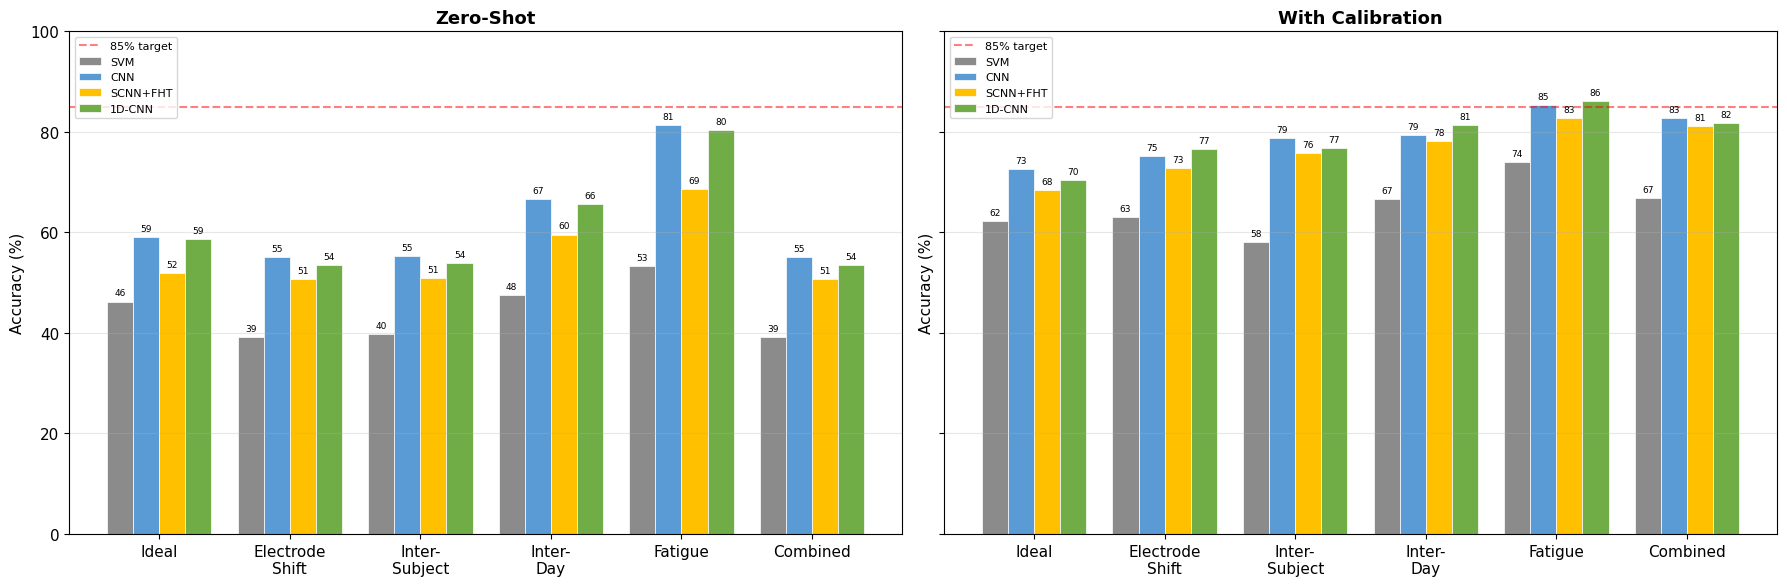

In [8]:
os.makedirs('results/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
x = np.arange(len(scenarios))
width = 0.2

for ax_idx, (title, data) in enumerate([('Zero-Shot', zero_shot), ('With Calibration', calibrated)]):
    ax = axes[ax_idx]
    for i, m in enumerate(methods):
        vals = [data[m][s] for s in scenarios]
        bars = ax.bar(x + i*width - 1.5*width, vals, width, label=m, color=colors[i], edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels([scenario_names[s] for s in scenarios])
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='85% target')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/final_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Radar Chart (Calibrated, S1-S6)

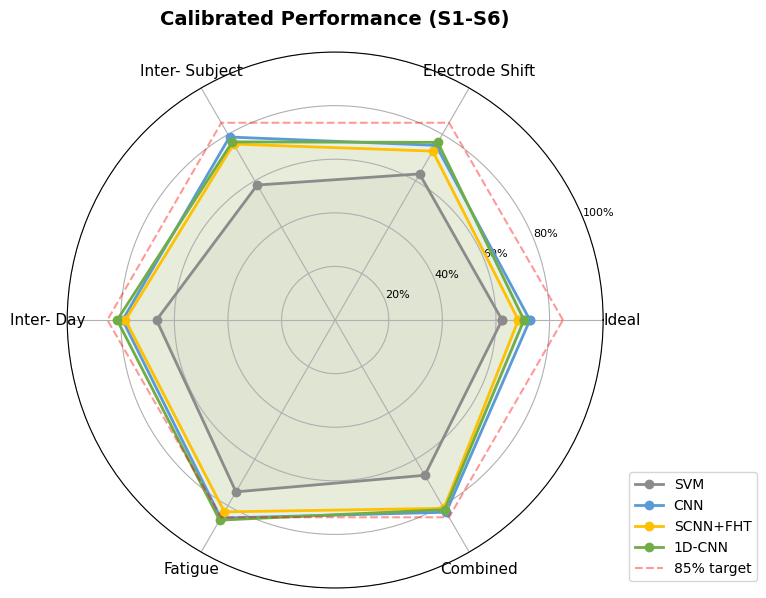

In [9]:
angles = np.linspace(0, 2*np.pi, len(scenarios), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, m in enumerate(methods):
    vals = [calibrated[m][s] for s in scenarios]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=m, color=colors[i], markersize=6)
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

target = [85] * (len(scenarios) + 1)
ax.plot(angles, target, '--', color='red', alpha=0.4, linewidth=1.5, label='85% target')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([scenario_names[s].replace('\n', ' ') for s in scenarios], fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('Calibrated Performance (S1-S6)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/final_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Calibration Improvement per Method

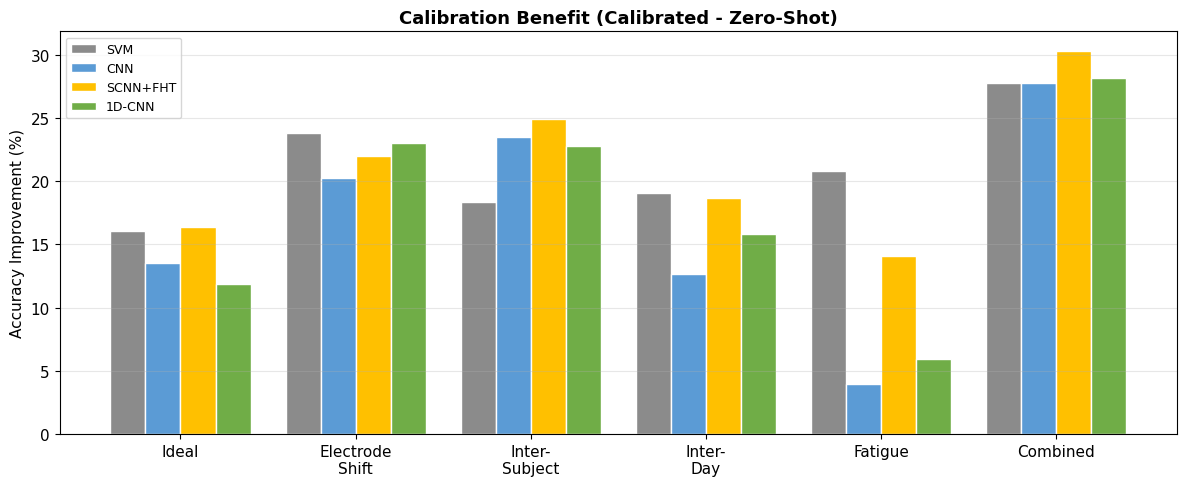

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(scenarios))
width = 0.2

for i, m in enumerate(methods):
    deltas = [calibrated[m][s] - zero_shot[m][s] for s in scenarios]
    ax.bar(x + i*width - 1.5*width, deltas, width, label=m, color=colors[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([scenario_names[s] for s in scenarios])
ax.set_ylabel('Accuracy Improvement (%)')
ax.set_title('Calibration Benefit (Calibrated - Zero-Shot)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/final_calibration_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Efficiency: Accuracy vs Parameters

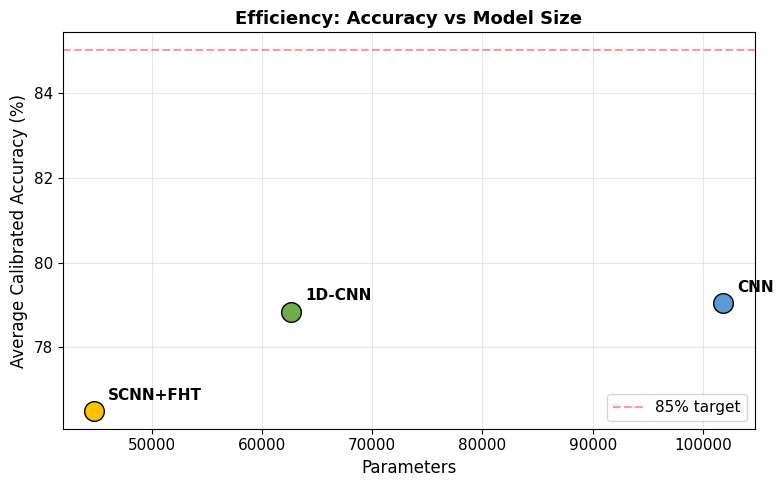

In [11]:
param_nums = {'CNN': 101831, 'SCNN+FHT': 44764, '1D-CNN': 62676}
dl_methods = ['CNN', 'SCNN+FHT', '1D-CNN']

fig, ax = plt.subplots(figsize=(8, 5))
for m in dl_methods:
    avg_cal = np.mean([calibrated[m][s] for s in scenarios])
    c = colors[methods.index(m)]
    ax.scatter(param_nums[m], avg_cal, s=200, color=c, edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(m, (param_nums[m], avg_cal), textcoords='offset points',
                xytext=(10, 8), fontsize=11, fontweight='bold')

ax.axhline(y=85, color='red', linestyle='--', alpha=0.4, label='85% target')
ax.set_xlabel('Parameters', fontsize=12)
ax.set_ylabel('Average Calibrated Accuracy (%)', fontsize=12)
ax.set_title('Efficiency: Accuracy vs Model Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/final_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — S8: Few-Shot Calibration Curve

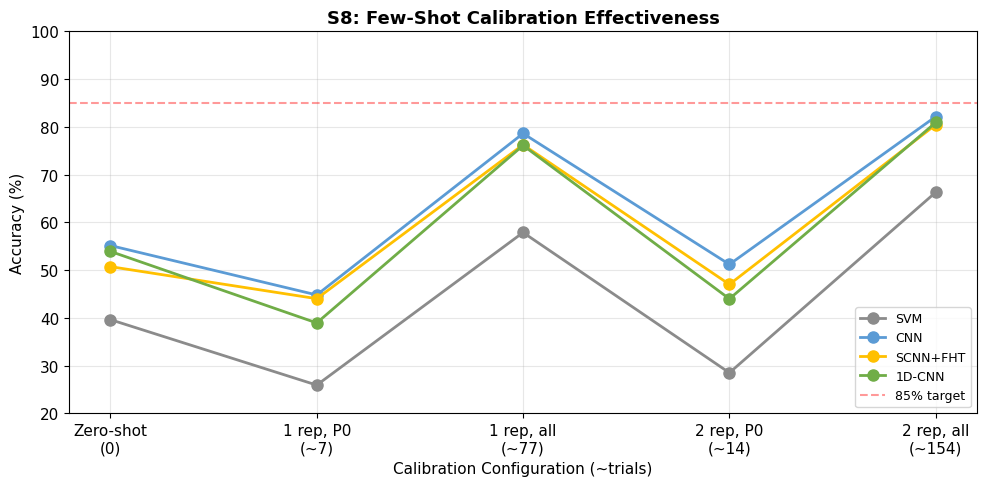

In [12]:
s8_trials = [0, 7, 77, 14, 154]
s8_labels_short = ['0', '7', '77', '14', '154']

fig, ax = plt.subplots(figsize=(10, 5))
for i, m in enumerate(methods):
    vals = [s8_results[m][cfg] for cfg in ['Zero-shot', '1 rep, p0', '1 rep, all', '2 rep, p0', '2 rep, all']]
    ax.plot(range(len(vals)), vals, 'o-', label=m, color=colors[i], linewidth=2, markersize=8)

ax.axhline(y=85, color='red', linestyle='--', alpha=0.4, label='85% target')
ax.set_xticks(range(5))
ax.set_xticklabels(['Zero-shot\n(0)', '1 rep, P0\n(~7)', '1 rep, all\n(~77)', '2 rep, P0\n(~14)', '2 rep, all\n(~154)'])
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Calibration Configuration (~trials)')
ax.set_title('S8: Few-Shot Calibration Effectiveness', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(20, 100)
plt.tight_layout()
plt.savefig('results/figures/final_s8_fewshot.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings Summary

In [13]:
print('=' * 70)
print('  KEY FINDINGS')
print('=' * 70)

print('\n1. Best method per scenario (calibrated):')
for s in scenarios:
    vals = {m: calibrated[m][s] for m in methods}
    best = max(vals, key=vals.get)
    print(f'   {s} ({scenario_names[s].replace(chr(10), " "):>15}): {best} ({vals[best]:.2f}%)')

print('\n2. Average accuracy across S1-S6:')
for label, data in [('Zero-shot', zero_shot), ('Calibrated', calibrated)]:
    print(f'   {label}:')
    avgs = {m: np.mean([data[m][s] for s in scenarios]) for m in methods}
    for m in sorted(avgs, key=avgs.get, reverse=True):
        print(f'     {m:<12} {avgs[m]:.2f}%')

print('\n3. Calibration benefit (average delta):')
for m in methods:
    avg_d = np.mean([calibrated[m][s] - zero_shot[m][s] for s in scenarios])
    print(f'   {m:<12} +{avg_d:.2f}%')

print('\n4. Scenarios reaching >=85% (calibrated):')
for m in methods:
    above = [s for s in scenarios if calibrated[m][s] >= 85]
    print(f'   {m:<12} {len(above)}/{len(scenarios)}: {", ".join(above) if above else "none"}')

print('\n5. S7 Gradual Shift (avg shifted accuracy):')
for m in sorted(s7_shifted_avg, key=s7_shifted_avg.get, reverse=True):
    print(f'   {m:<12} {s7_shifted_avg[m]:.2f}%')

print('\n' + '=' * 70)
print('  CONCLUSION')
print('=' * 70)

best_zs = max(methods, key=lambda m: np.mean([zero_shot[m][s] for s in scenarios]))
best_cal = max(methods, key=lambda m: np.mean([calibrated[m][s] for s in scenarios]))

print(f'\n  Best zero-shot:     {best_zs} (avg {np.mean([zero_shot[best_zs][s] for s in scenarios]):.2f}%)')
print(f'  Best calibrated:    {best_cal} (avg {np.mean([calibrated[best_cal][s] for s in scenarios]):.2f}%)')
print(f'  Most efficient:     SCNN+FHT (44,764 params)')
print(f'  Best trade-off:     1D-CNN (highest calibrated accuracy, moderate size)')
print(f'\n  Zero-shot alone is insufficient for non-ideal conditions.')
print(f'  Calibration significantly improves all methods.')
print(f'  1D-CNN + calibration achieves the best overall performance.')
print('=' * 70)

  KEY FINDINGS

1. Best method per scenario (calibrated):
   S1 (          Ideal): CNN (72.66%)
   S2 (Electrode Shift): 1D-CNN (76.57%)
   S3 ( Inter- Subject): CNN (78.86%)
   S4 (     Inter- Day): 1D-CNN (81.37%)
   S5 (        Fatigue): 1D-CNN (86.23%)
   S6 (       Combined): CNN (82.82%)

2. Average accuracy across S1-S6:
   Zero-shot:
     CNN          62.10%
     1D-CNN       60.91%
     SCNN+FHT     55.42%
     SVM          44.20%
   Calibrated:
     CNN          79.05%
     1D-CNN       78.85%
     SCNN+FHT     76.51%
     SVM          65.17%

3. Calibration benefit (average delta):
   SVM          +20.97%
   CNN          +16.94%
   SCNN+FHT     +21.09%
   1D-CNN       +17.93%

4. Scenarios reaching >=85% (calibrated):
   SVM          0/6: none
   CNN          1/6: S5
   SCNN+FHT     0/6: none
   1D-CNN       1/6: S5

5. S7 Gradual Shift (avg shifted accuracy):
   1D-CNN       79.92%
   CNN          77.66%
   SCNN+FHT     62.90%
   SVM          43.72%

  CONCLUSION

  Best ze